In [1]:
# ============================================================
# SOCIAL MEDIA SENTIMENT ANALYSIS - END TO END NOTEBOOK
# ============================================================
# This notebook:
# 1. Loads social media/tweet dataset
# 2. Cleans text using NLP
# 3. Performs EDA
# 4. Converts text to numerical features using TF-IDF
# 5. Trains ML models
# 6. Evaluates performance
# 7. Predicts sentiment for new text
# 8. Saves the trained model
#
# Dataset format expected:
# -----------------------------------
# text,sentiment
# "I love this movie",positive
# "Worst product ever",negative
#
# Sentiments:
# positive / negative / neutral
# ============================================================

In [2]:
# ============================================================
# 1. INSTALL & IMPORT LIBRARIES
# ============================================================

# Uncomment if running first time
%%capture
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

In [3]:
%%capture
!pip install kagglehub[pandas-datasets]

In [4]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

nltk.download('stopwords')
nltk.download('wordnet')

print("IMPORT")

IMPORT


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Correct file name inside the dataset
file_path = "training.1600000.processed.noemoticon.csv"

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kazanova/sentiment140",
    file_path,
    pandas_kwargs={
        "encoding": "latin-1",
        "header": None
    }
)

# Optional: rename columns
df.columns = [
    "target",
    "id",
    "date",
    "flag",
    "user",
    "text"
]

df.head()

/tmp/ipykernel_4102/916581457.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
# ============================================================
# 3. BASIC EDA
# ============================================================

print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(1600000, 6)


In [7]:
df['sentiment'] = df['target'].map({4 : 'positive',
                                    0 : 'negative'})

In [8]:
print("\nClass Distribution:")
print(df['sentiment'].value_counts())


Class Distribution:
sentiment
negative    800000
positive    800000
Name: count, dtype: int64


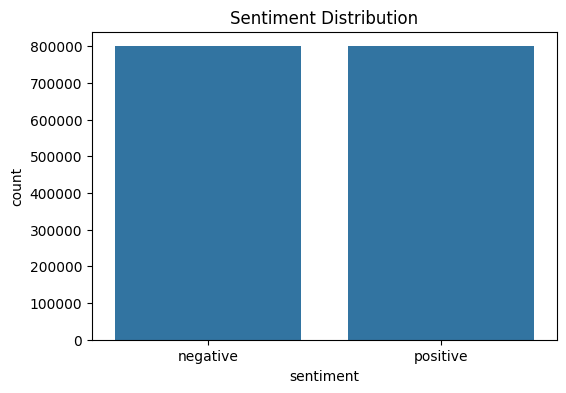

In [9]:
# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [10]:
# ============================================================
# 4. TEXT CLEANING / NLP PREPROCESSING
# ============================================================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

In [11]:
print("\nCleaned Data:")
df[['text', 'clean_text']].head()


Cleaned Data:


,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",thats bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see


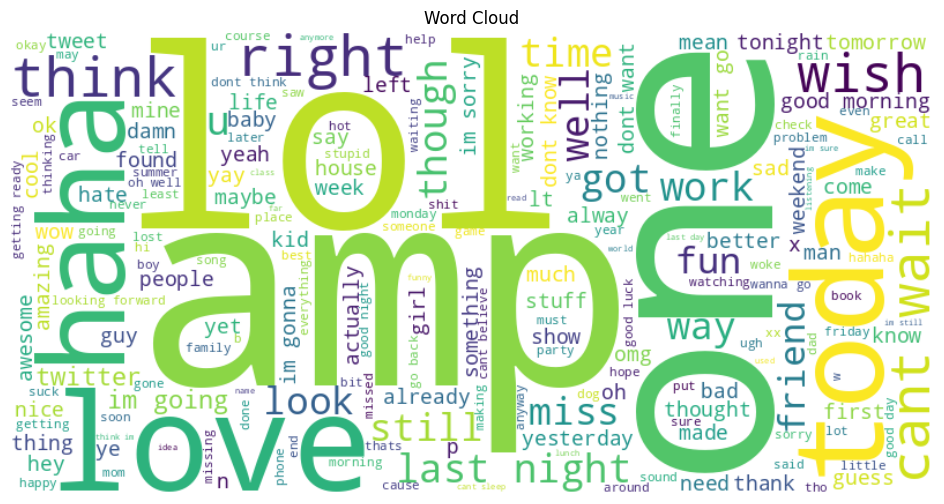

In [12]:
# ============================================================
# 5. WORD CLOUD VISUALIZATION
# ============================================================

all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [13]:
# ============================================================
# 6. TRAIN TEST SPLIT
# ============================================================

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Size:", len(X_train))
print("Test Size:", len(X_test))


Train Size: 1280000
Test Size: 320000


In [14]:
# ============================================================
# 7. TF-IDF + MACHINE LEARNING PIPELINE
# ============================================================

# Logistic Regression Pipeline

logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression(max_iter=1000))
])

# Train model
logistic_pipeline.fit(X_train, y_train)

# Predictions
y_pred = logistic_pipeline.predict(X_test)


Accuracy: 0.782446875

Classification Report:

              precision    recall  f1-score   support

    negative       0.79      0.76      0.78    160000
    positive       0.77      0.80      0.79    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



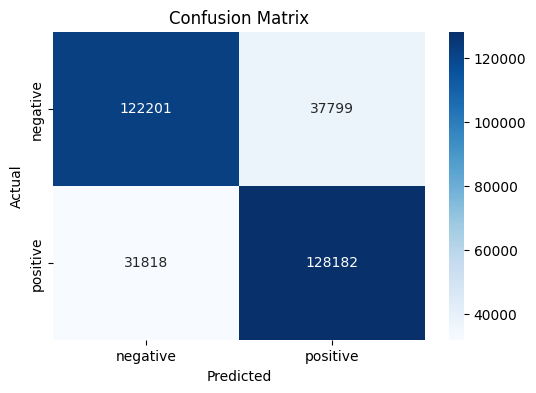

In [15]:
# ============================================================
# 8. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
# ============================================================
# 9. COMPARE MULTIPLE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[model_name] = acc

# Display results
results_df = pd.DataFrame(
    results.items(),
    columns=['Model', 'Accuracy']
)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.782447
1          Naive Bayes  0.763581
2           Linear SVM  0.775525


In [17]:
# ============================================================
# 10. PREDICT CUSTOM SENTENCES
# ============================================================

# Custom sentences to test
sample_texts = [
    "I really love this phone",
    "Worst experience ever",
    "The movie was okay",
    "Amazing customer support",
    "I hate this app"
]

# --------------------------------------------
# CLEAN TEXT
# --------------------------------------------

cleaned_samples = [clean_text(text) for text in sample_texts]

# --------------------------------------------
# PREDICT USING TRAINED MODEL
# --------------------------------------------

predictions = logistic_pipeline.predict(cleaned_samples)

# --------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------

for text, pred in zip(sample_texts, predictions):

    print(f"Text       : {text}")
    print(f"Prediction : {pred}")
    print("-" * 50)

Text       : I really love this phone
Prediction : positive
--------------------------------------------------
Text       : Worst experience ever
Prediction : negative
--------------------------------------------------
Text       : The movie was okay
Prediction : positive
--------------------------------------------------
Text       : Amazing customer support
Prediction : positive
--------------------------------------------------
Text       : I hate this app
Prediction : negative
--------------------------------------------------


In [18]:
# ============================================================
# 11. SAVE MODEL
# ============================================================

joblib.dump(logistic_pipeline, "sentiment_model.pkl")

print("\nModel saved successfully!")


Model saved successfully!


In [19]:
# ============================================================
# 12. LOAD MODEL & PREDICT AGAIN
# ============================================================

loaded_model = joblib.load("sentiment_model.pkl")

new_text = ["I absolutely love this amazing app"]

cleaned_new_text = [clean_text(t) for t in new_text]

prediction = loaded_model.predict(cleaned_new_text)

print("\nLoaded Model Prediction:")
print(prediction)


Loaded Model Prediction:
['positive']
